# 🛒 Customer Purchase Prediction with Logistic Regression

This project builds a Logistic Regression classifier to predict whether a customer will purchase a product based on their Age and Estimated Salary. The dataset used is from rakeshrau/social-network-ads.

We implement two versions:
1. **Plain Logistic Regression** (linear decision boundary)
2. **Regularized Logistic Regression** with polynomial feature mapping (non-linear decision boundary)

---

## Table of Contents
- [1 - Packages](#1)
- [2 - Logistic Regression](#2)
  - [2.1 Problem Statement](#2.1)
  - [2.2 Loading and visualizing the data](#2.2)
  - [2.3 Sigmoid function](#2.3)
  - [2.4 Cost function for logistic regression](#2.4)
  - [2.5 Gradient for logistic regression](#2.5)
  - [2.6 Learning parameters using gradient descent](#2.6)
  - [2.7 Plotting the decision boundary](#2.7)
  - [2.8 Evaluating logistic regression](#2.8)
- [3 - Regularized Logistic Regression](#3)
  - [3.1 Problem Statement](#3.1)
  - [3.2 Loading and visualizing the data](#3.2)
  - [3.3 Feature mapping](#3.3)
  - [3.4 Cost function for regularized logistic regression](#3.4)
  - [3.5 Gradient for regularized logistic regression](#3.5)
  - [3.6 Learning parameters using gradient descent](#3.6)
  - [3.7 Plotting the decision boundary](#3.7)
  - [3.8 Evaluating regularized logistic regression model](#3.8)


<a id='1'></a>
# 1. Packages & Data Load

In [1]:
!pip install -q kagglehub scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

np.random.seed(1)
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None
%matplotlib inline

In [3]:
dataset_path = kagglehub.dataset_download("rakeshrau/social-network-ads")
print("Dataset downloaded to:", dataset_path)

import os
print("Files:", os.listdir(dataset_path))

Using Colab cache for faster access to the 'social-network-ads' dataset.
Dataset downloaded to: /kaggle/input/social-network-ads
Files: ['Social_Network_Ads.csv']


In [4]:
csv_file = [f for f in os.listdir(dataset_path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(dataset_path, csv_file))
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


<a id='2'></a>
# 2. Logistic Regression #

<a id='2.1'></a>
## 2.1 Problem Statement

Suppose you are working as a Data Analyst for a company that advertises
its products through social media.

The marketing team wants to understand whether a customer is likely to
purchase a product after seeing an advertisement.

Historical customer data contains:

- Age
- Estimated Salary
- Purchase Decision

The goal is to build a logistic regression model that predicts whether
a customer will purchase the product.

Target:

- Purchased = 1 → Customer purchased the product
- Purchased = 0 → Customer did not purchase the product

<a id='2.2'></a>
## 2.2 Loading and visualizing the data


In [8]:
X_raw = df[['Age', 'EstimatedSalary']].values.astype(float)
y = df['Purchased'].values.astype(float)

**View the variables**

In [7]:
print("First five elements in X_train are:\n", X_raw[:5])
print("Type of X_train:",type(X_raw))

First five elements in X_train are:
 [[1.9e+01 1.9e+04]
 [3.5e+01 2.0e+04]
 [2.6e+01 4.3e+04]
 [2.7e+01 5.7e+04]
 [1.9e+01 7.6e+04]]
Type of X_train: <class 'numpy.ndarray'>


In [9]:
print("First five elements in y_train are:\n", y[:5])
print("Type of y_train:",type(y))

First five elements in y_train are:
 [0. 0. 0. 0. 0.]
Type of y_train: <class 'numpy.ndarray'>


**Check the dimensions of your variables¶**

In [11]:
print ('The shape of X_train is: ' + str(X_raw.shape))
print ('The shape of y_train is: ' + str(y.shape))
print ('We have m = %d training examples' % (len(y)))
print('Positive class (Purchased=1) ratio: {:.2f}%'.format(100 * y.mean()))

The shape of X_train is: (400, 2)
The shape of y_train is: (400,)
We have m = 400 training examples
Positive class (Purchased=1) ratio: 35.75%


Age and EstimatedSalary are on very different scales (Age range is 18-60, otherwise Salary range is 15,000-150,000), which slows down gradient descent. We apply **z-score normalization** (standardization).


In [12]:
def zscore_normalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X, mu, sigma = zscore_normalize(X_raw)
print('mu:', mu)
print('sigma:', sigma)

mu: [3.76550e+01 6.97425e+04]
sigma: [1.04697648e+01 3.40543124e+04]


**Visualize your data**

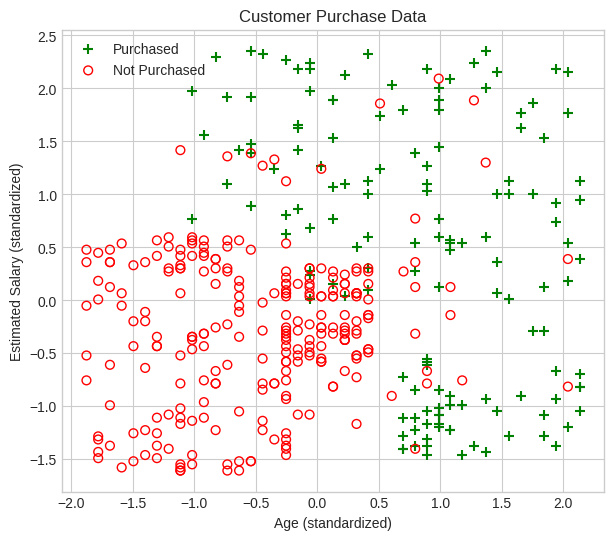

In [13]:
def plot_data(X, y, ax, pos_label='Purchased', neg_label='Not Purchased'):
    pos = y == 1
    neg = y == 0
    ax.scatter(X[pos, 0], X[pos, 1], marker='+', c='green', s=60, label=pos_label)
    ax.scatter(X[neg, 0], X[neg, 1], marker='o', edgecolors='red', facecolors='none', s=40, label=neg_label)
    ax.set_xlabel('Age (standardized)')
    ax.set_ylabel('Estimated Salary (standardized)')
    ax.legend(loc='best')

fig, ax = plt.subplots(figsize=(7, 6))
plot_data(X, y, ax)
ax.set_title('Customer Purchase Data')
plt.show()


<a id='2.3'></a>
## 2.3 Sigmoid function

Recall that for logistic regression, the model is represented as

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$
where function $g$ is the sigmoid function.

Logistic regression uses the sigmoid (logistic) function to map any real value into the range (0, 1)n is defined as:

$$g(z) = \frac{1}{1+e^{-z}}$$

Let's implement the sigmoid function first, so it can be used by the rest of this assignment.


In [14]:
def sigmoid(z):
    z = np.clip(z, -500, 500)  # avoid overflow
    g = 1 / (1 + np.exp(-z))
    return g

In [15]:
# Quick check
print('sigmoid(0) =', sigmoid(0))
print('sigmoid([-5, 0, 5]) =', sigmoid(np.array([-5, 0, 5])))


sigmoid(0) = 0.5
sigmoid([-5, 0, 5]) = [0.00669285 0.5        0.99330715]


The sigmoid function behaves as expected. When z=0, the output is 0.5. As z becomes more negative, the output approaches 0, while as z becomes more positive, the output approaches 1. This allows logistic regression to convert the linear output z=w⋅x+b into a probability between 0 and 1.

<a id='2.4'></a>
## 2.4 Cost function for logistic regression

The (unregularized) logistic regression cost function is:

$$J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\right]$$

where $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b)$ and $g$ is the sigmoid function.

In [16]:
def compute_cost(X, y, w, b, *argv):
    """
    Computes the cost over all examples
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (ndarray Shape (m,))  target value
      w : (ndarray Shape (n,))  values of parameters of the model
      b : (scalar)              value of bias parameter of the model
      *argv : unused, for compatibility with regularized version below
    Returns:
      total_cost : (scalar) cost
    """

    m, n = X.shape
    cost = 0
    for i in range(m):
        z_wb = np.dot(X[i], w) + b
        f_wb = sigmoid(z_wb)
        loss = -y[i] * np.log(f_wb) - (1 - y[i]) * np.log(1 - f_wb)
        cost += loss
    total_cost = cost / m

    return total_cost

In [17]:
# Compute and display cost with w and b initialized to zeros
n = X.shape[1]
w_init = np.zeros(n)
b_init = 0.0
print('Cost at initial w,b (zeros):', compute_cost(X, y, w_init, b_init))

Cost at initial w,b (zeros): 0.6931471805599467


<a id='2.5'></a>
## 2.5 Gradient for logistic regression

The gradient of the cost function has the same form as linear regression, only $f_{\mathbf{w},b}$ is now the sigmoid output:

$$\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} \left(f_{\mathbf{w},b}\left(\mathbf{x}^{(i)}\right) - y^{(i)}\right)$$
$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \frac{1}{m} \sum_{i=0}^{m-1} \left(f_{\mathbf{w},b}\left(\mathbf{x}^{(i)}\right) - y^{(i)}\right)x_j^{(i)}$$


In [18]:
def compute_gradient(X, y, w, b, *argv):
    """
    Computes the gradient for logistic regression

    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (ndarray Shape (m,))  target value
      w : (ndarray Shape (n,))  values of parameters of the model
      b : (scalar)              value of bias parameter of the model
      *argv : unused, for compatibility with regularized version below
    Returns
      dj_dw : (ndarray Shape (n,)) The gradient of the cost w.r.t. the parameters w.
      dj_db : (scalar)             The gradient of the cost w.r.t. the parameter b.
    """
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb += w[j] * X[i][j]
        z_wb += b
        f_wb = sigmoid(z_wb)

        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i

        for j in range(n):
            dj_dw[j] += (f_wb - y[i]) * X[i][j]

    dj_dw = dj_dw / m
    dj_db = dj_db / m


    return dj_db, dj_dw

In [19]:
dj_db, dj_dw = compute_gradient(X, y, w_init, b_init)

print('dj_db at initial w,b:', dj_db)
print('dj_dw at initial w,b:', dj_dw)

dj_db at initial w,b: 0.1425
dj_dw at initial w,b: [-0.29831974 -0.17353327]


<a id='2.6'></a>
## 2.6 Learning parameters using gradient descent


In [20]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_=0):
    """
    Performs batch gradient descent to learn w, b
    Returns:
        w, b : learned parameters
        J_history : list of cost values recorded at each iteration
    """
    J_history = []
    w = w_in.copy()
    b = b_in

    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w, b, lambda_)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:
            J_history.append(cost_function(X, y, w, b, lambda_))

        if i % (num_iters // 10) == 0 or i == num_iters - 1:
            print(f'Iteration {i:5d}: Cost {J_history[-1]:.4f}')

    return w, b, J_history


In [21]:
np.random.seed(1)
w_init = np.zeros(n)
b_init = 0.0
alpha = 0.5
iterations = 2000

w, b, J_history = gradient_descent(X, y, w_init, b_init, compute_cost, compute_gradient, alpha, iterations)
print('\nLearned parameters: w =', w, ' b =', b)


Iteration     0: Cost 0.6283
Iteration   200: Cost 0.3464
Iteration   400: Cost 0.3463
Iteration   600: Cost 0.3463
Iteration   800: Cost 0.3463
Iteration  1000: Cost 0.3463
Iteration  1200: Cost 0.3463
Iteration  1400: Cost 0.3463
Iteration  1600: Cost 0.3463
Iteration  1800: Cost 0.3463
Iteration  1999: Cost 0.3463

Learned parameters: w = [2.44457954 1.22258176]  b = -1.1381219656497736


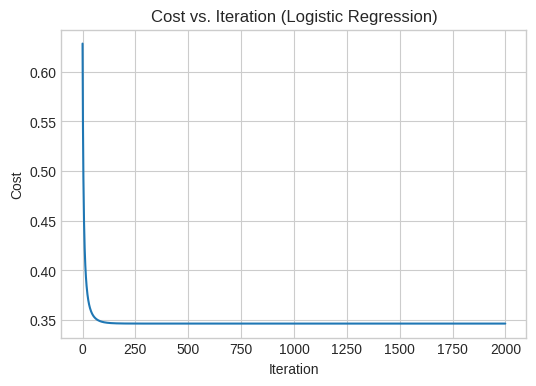

In [22]:
plt.figure(figsize=(6,4))
plt.plot(J_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs. Iteration (Logistic Regression)')
plt.show()


<a id='2.7'></a>
## 2.7 Plotting the decision boundary

With two features, the decision boundary is the line where $\mathbf{w}\cdot\mathbf{x}+b = 0$, i.e. $x_2 = -\left(\dfrac{w_1}{w_2}\right)x_1 - \dfrac{b}{w_2}$.


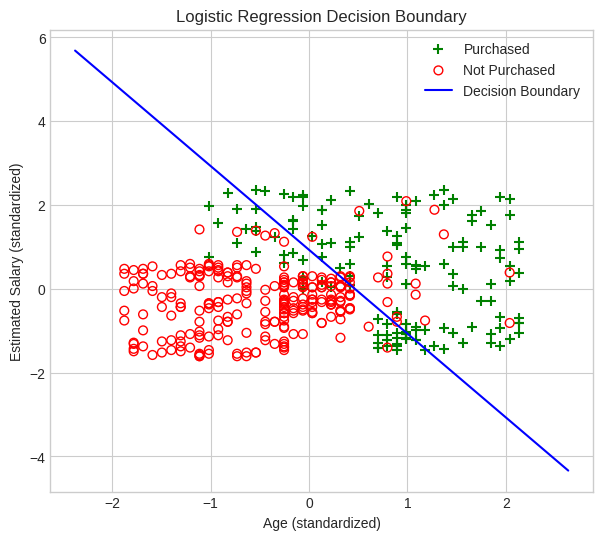

In [23]:
def plot_decision_boundary(w, b, X, y):
    fig, ax = plt.subplots(figsize=(7,6))
    plot_data(X, y, ax)

    x1 = np.array([np.min(X[:, 0]) - 0.5, np.max(X[:, 0]) + 0.5])
    x2 = -(w[0] * x1 + b) / w[1]

    ax.plot(x1, x2, c='blue', label='Decision Boundary')
    ax.set_title('Logistic Regression Decision Boundary')
    ax.legend(loc='best')
    plt.show()

plot_decision_boundary(w, b, X, y)


<a id='2.8'></a>
## 2.8 Evaluating logistic regression


In [24]:
def predict(X, w, b, threshold=0.5):
    """
    Predict whether the label is 0 or 1 using learned logistic regression parameters w,b
    """
    p = sigmoid(X @ w + b)
    return (p >= threshold).astype(int)


In [25]:
p = predict(X, w, b)
train_accuracy = np.mean(p == y) * 100
print(f'Train Accuracy: {train_accuracy:.2f}%')


Train Accuracy: 84.50%


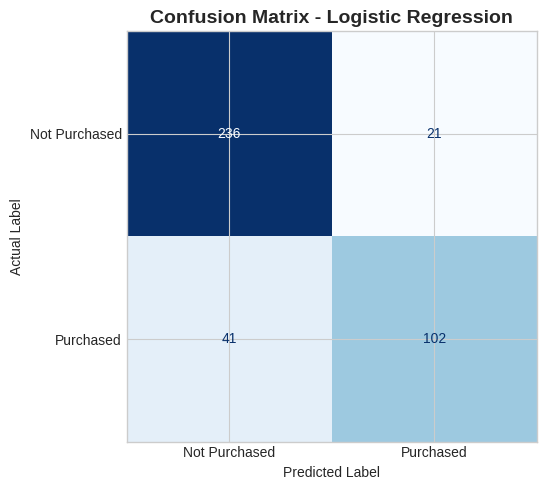

               precision    recall  f1-score   support

Not Purchased       0.85      0.92      0.88       257
    Purchased       0.83      0.71      0.77       143

     accuracy                           0.84       400
    macro avg       0.84      0.82      0.83       400
 weighted avg       0.84      0.84      0.84       400



In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report)

# Confusion Matrix
cm = confusion_matrix(y, p)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    colorbar=False
)

plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# Classification Report
print(classification_report(y,p,target_names=['Not Purchased', 'Purchased']))

<a id='3'></a>
# 3. Regularized Logistic Regression


<a id='3.1'></a>
## 3.1 Problem Statement

Looking at the plot above, the two customer classes are **not perfectly linearly separable**, that means a straight line underfits the pattern near the boundary. To capture the non-linear relationship between Age, Salary, and purchase behavior, we will:
1. Map the two original features into a higher-degree **polynomial feature space**,
2. Train a logistic regression model on those features,
3. Use **L2 regularization** to prevent the added model complexity from overfitting the training data.


<a id='3.2'></a>
## 3.2 Loading and visualizing the data

We reuse the same standardized Age / EstimatedSalary features and Purchased labels loaded in section 2.2.


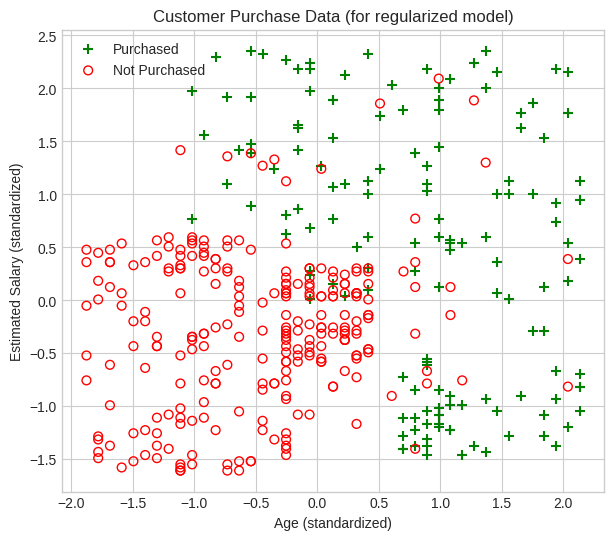

In [27]:
fig, ax = plt.subplots(figsize=(7,6))
plot_data(X, y, ax)
ax.set_title('Customer Purchase Data (for regularized model)')
plt.show()


<a id='3.3'></a>
## 3.3 Feature mapping

We map the two features into all polynomial terms of Age and EstimatedSalary up to a sixth degree. This lets a *linear* model in the new feature space represent a *non-linear* boundary in the original 2D space.

$$\mathrm{map\_feature}(x) =
\left[\begin{array}{c}
x_1\\
x_2\\
x_1^2\\
x_1 x_2\\
x_2^2\\
x_1^3\\
\vdots\\
x_1 x_2^5\\
x_2^6\end{array}\right]$$

As a result of this mapping, our vector of two features (Age and EstimatedSalary) has been transformed into a 27-dimensional vector.

In [28]:
def map_feature(X1, X2, degree=6):
    """
    Feature mapping function to polynomial features up to the given degree.
    Returns a new feature matrix with columns:
    X1, X2, X1^2, X1*X2, X2^2, X1^3, ..., X2^degree
    """
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2)
    out = []
    for i in range(1, degree + 1):
        for j in range(i + 1):
            out.append((X1 ** (i - j)) * (X2 ** j))
    return np.stack(out, axis=1)


In [29]:
degree = 6
X_mapped = map_feature(X[:, 0], X[:, 1], degree=degree)
print('Original feature shape:', X.shape)
print('Mapped feature shape:', X_mapped.shape)


Original feature shape: (400, 2)
Mapped feature shape: (400, 27)


**Feature Scalling**

In [32]:
mu_map = X_mapped.mean(axis=0)
sigma_map = X_mapped.std(axis=0)
X_mapped_norm = (X_mapped - mu_map) / sigma_map

print('Scale BEFORE normalizing -> min std: {:.2f}, max std: {:.2f}'.format(
    X_mapped.std(axis=0).min(), X_mapped.std(axis=0).max()))
print('Scale AFTER normalizing  -> min std: {:.2f}, max std: {:.2f}'.format(
    X_mapped_norm.std(axis=0).min(), X_mapped_norm.std(axis=0).max()))


Scale BEFORE normalizing -> min std: 1.00, max std: 26.71
Scale AFTER normalizing  -> min std: 1.00, max std: 1.00


<a id='3.4'></a>
## 3.4 Cost function for regularized logistic regression

Recall that for regularized logistic regression, the cost function is of the form
$$J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$

Compare this to the cost function without regularization (which you implemented above), which is of the form

$$ J(\mathbf{w}.b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\right]$$

The difference is the regularization term, which is $$\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$
Note that the $b$ parameter is not regularized.

In [33]:
def compute_cost_reg(X, y, w, b, lambda_=1):
    """
    Computes the cost for regularized logistic regression
    """
    m, n = X.shape
    cost_unreg = compute_cost(X, y, w, b)
    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)
    total_cost = cost_unreg + reg_cost
    return total_cost


In [34]:
w_tmp = np.zeros(X_mapped_norm.shape[1])
b_tmp = 0.0

print('Regularized cost at initial w (zeros):',compute_cost_reg(X_mapped_norm, y, w_tmp, b_tmp, lambda_=1))


Regularized cost at initial w (zeros): 0.6931471805599467


<a id='3.5'></a>
## 3.5 Gradient for regularized logistic regression

The gradient of the regularized cost function has two components. The first, $\frac{\partial J(\mathbf{w},b)}{\partial b}$ is a scalar, the other is a vector with the same shape as the parameters $\mathbf{w}$, where the $j^\mathrm{th}$ element is defined as follows:

$$\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})  $$

$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \left( \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) x_j^{(i)} \right) + \frac{\lambda}{m} w_j  \quad\, \mbox{for $j=0...(n-1)$}$$



In [35]:
def compute_gradient_reg(X, y, w, b, lambda_=1):
    """
    Computes the gradient for logistic regression with regularization

    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (ndarray Shape (m,))  target value
      w : (ndarray Shape (n,))  values of parameters of the model
      b : (scalar)              value of bias parameter of the model
      lambda_ : (scalar,float)  regularization constant

    Returns
      dj_db : (scalar)             The gradient of the cost w.r.t. b
      dj_dw : (ndarray Shape (n,)) The gradient of the cost w.r.t. w
    """
    m, n = X.shape

    # Gradient logistic regression biasa
    dj_db, dj_dw = compute_gradient(X, y, w, b)

    # Tambahkan regularization hanya ke w
    dj_dw = dj_dw + (lambda_ / m) * w

    return dj_db, dj_dw

In [36]:
dj_db, dj_dw = compute_gradient_reg(
    X_mapped_norm,
    y,
    w_tmp,
    b_tmp,
    lambda_=1
)

print('dj_db:', dj_db)
print('dj_dw[:5]:', dj_dw[:5])


dj_db: 0.1425
dj_dw[:5]: [-0.29831974 -0.17353327 -0.11245616  0.0419123  -0.21322162]


<a id='3.6'></a>
## 3.6 Learning parameters using gradient descent


In [37]:
np.random.seed(1)
w_init = np.zeros(X_mapped_norm.shape[1])
b_init = 0.0
lambda_ = 0.5
alpha = 0.3
iterations = 4000

w_reg, b_reg, J_history_reg = gradient_descent(
    X_mapped_norm, y, w_init, b_init, compute_cost_reg, compute_gradient_reg, alpha, iterations, lambda_
)
print('\nLearned parameters: b =', b_reg)


Iteration     0: Cost 0.5522
Iteration   400: Cost 0.2468
Iteration   800: Cost 0.2411
Iteration  1200: Cost 0.2391
Iteration  1600: Cost 0.2383
Iteration  2000: Cost 0.2379
Iteration  2400: Cost 0.2377
Iteration  2800: Cost 0.2376
Iteration  3200: Cost 0.2375
Iteration  3600: Cost 0.2374
Iteration  3999: Cost 0.2374

Learned parameters: b = -1.835845831542887


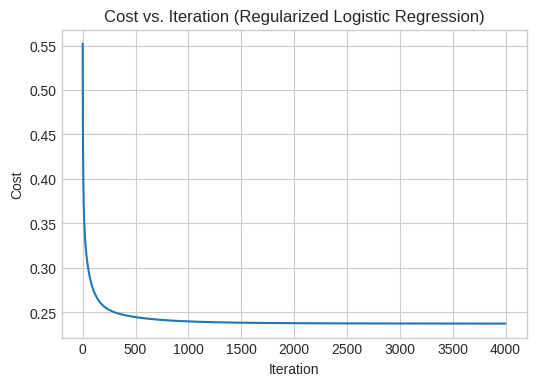

In [38]:
plt.figure(figsize=(6,4))
plt.plot(J_history_reg)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs. Iteration (Regularized Logistic Regression)')
plt.show()


<a id='3.7'></a>
## 3.7 Plotting the decision boundary

Since the model is no longer linear in the original feature space, we plot the boundary as a **contour** where $\mathbf{w}\cdot\phi(\mathbf{x})+b = 0$, with $\phi$ the polynomial feature mapping.


/tmp/ipykernel_29675/1989023144.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i, j] = mapped_norm @ w + b


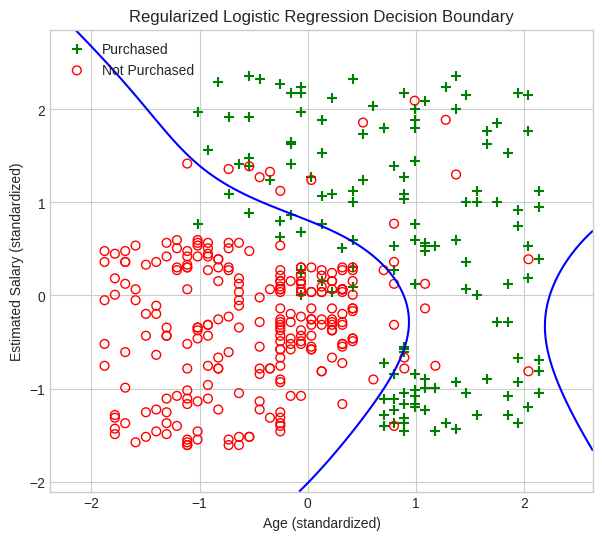

In [39]:
def plot_decision_boundary_reg(w, b, X, y, degree=6):
    fig, ax = plt.subplots(figsize=(7,6))
    plot_data(X, y, ax)

    u = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
    v = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200)
    z = np.zeros((len(u), len(v)))

    for i in range(len(u)):
        for j in range(len(v)):
            mapped = map_feature(np.array([u[i]]), np.array([v[j]]), degree=degree)
            mapped_norm = (mapped - mu_map) / sigma_map   # use the SAME mu/sigma as training
            z[i, j] = mapped_norm @ w + b

    z = z.T
    ax.contour(u, v, z, levels=[0], colors='blue')
    ax.set_title('Regularized Logistic Regression Decision Boundary')
    plt.show()

plot_decision_boundary_reg(w_reg, b_reg, X, y, degree=degree)


<a id='3.8'></a>
## 3.8 Evaluating regularized logistic regression model


In [40]:
p_reg = predict(X_mapped_norm, w_reg, b_reg)
train_accuracy_reg = np.mean(p_reg == y) * 100
print(f'Train Accuracy (regularized, degree={degree}): {train_accuracy_reg:.2f}%')


Train Accuracy (regularized, degree=6): 90.75%


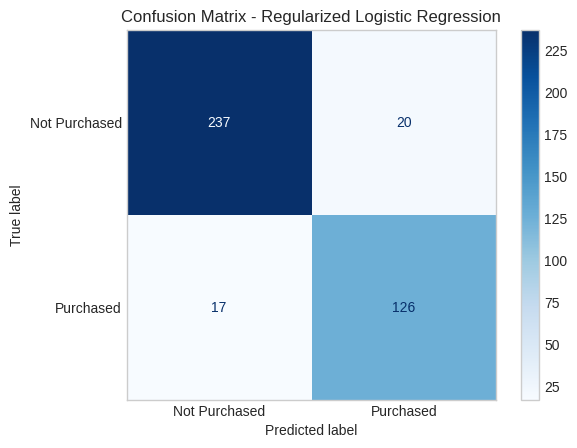


Classification Report:
                precision    recall  f1-score   support

Not Purchased       0.93      0.92      0.93       257
    Purchased       0.86      0.88      0.87       143

     accuracy                           0.91       400
    macro avg       0.90      0.90      0.90       400
 weighted avg       0.91      0.91      0.91       400



In [41]:
# Create confusion matrix
cm_reg = confusion_matrix(y, p_reg)

# Visualize
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_reg,
    display_labels=['Not Purchased', 'Purchased']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Regularized Logistic Regression')
plt.grid(False)
plt.show()

print('\nClassification Report:\n', classification_report(y, p_reg, target_names=['Not Purchased', 'Purchased']))


## Sanity check against scikit-learn
As a final check, we compare our from-scratch regularized model against scikit-learn's built-in `LogisticRegression` (L2 penalty) trained on the same mapped features.


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_mapped_norm, y, test_size=0.2, random_state=1, stratify=y)

sk_model = LogisticRegression(penalty='l2', C=1/lambda_, max_iter=5000)
sk_model.fit(X_train, y_train)
sk_acc = sk_model.score(X_test, y_test) * 100
print(f'scikit-learn LogisticRegression test accuracy: {sk_acc:.2f}%')


scikit-learn LogisticRegression test accuracy: 87.50%


# Summary

The Regularized Logistic Regression model improved training accuracy from 84.50% to 90.75%. The improvement was especially noticeable in identifying customers who actually purchased the product, with recall increasing from 0.71 to 0.88 and false negatives decreasing from 41 to 17. Overall, polynomial feature mapping helped capture more complex relationships in the data, while regularization controlled model complexity and resulted in better classification performance.